<a href="https://colab.research.google.com/github/EpiccSafe-Capstone/epicc-safe-system/blob/main/Capstone_Project_ML_(revisi).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset:
- training data -> [PhiUSIIL Phishing URL Dataset](https://www.kaggle.com/datasets/ndarvind/phiusiil-phishing-url-dataset)
- testing data -> [Malicious URL Detection Dataset](https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026)

# Penjelasan setiap datasetnya:
- PhiUSIIL Phishing URL Dataset:
phishing URL dikumpulkan secara langsung dari webpage yang diunduh, kemudian dilakukan ekstraksi fitur dari source code HTML halaman tersebut beserta struktur URL-nya. Kaggle Dataset ini difokuskan untuk mendeteksi serangan berbasis kemiripan visual seperti zero-width characters, homograph, punycode, homophone, bitsquatting, dan combosquatting — yaitu teknik phishing yang memanipulasi tampilan URL agar mirip dengan domain asli.
Bentuk data:
Dataset berisi 134.850 URL legitimate dan 100.945 URL phishing
-  Malicious URL Detection Dataset Enhanced 2026:
dataset ini merupakan versi yang diperkaya (enhanced) dari dataset malicious URL yang sudah ada sebelumnya, dengan URL yang dikategorikan ke dalam 4 kelas: Phishing, Benign, Malware, dan Defacement. URL phishing merupakan tiruan website legitimate yang menipu pengguna agar menyerahkan informasi rahasia termasuk kredensial login dan detail perbankan. ScienceDirect
Bentuk data:
Format CSV dengan kolom URL dan label kelas. Karena ini versi enhanced 2026, kemungkinan besar sudah menambahkan sampel-sampel URL terbaru yang lebih relevan dengan pola serangan siber terkini dibanding dataset 2021-2022

## Data Cleaning

Alur Pipeline
```
Load Data → Inspeksi Awal → Hapus Duplikat → Tangani Missing Values
→ Validasi Format URL → Normalisasi Label → Tangani Class Imbalance
→ Feature Selection (PhiUSIIL) → Simpan Data Bersih
```

In [ ]:
# install library
!pip install pandas numpy scikit-learn imbalanced-learn tldextract matplotlib seaborn

In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tldextract
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### Load dataset

In [ ]:
!pip install kagglehub[pandas-datasets] -q

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# Set the path to the file you'd like to load
file_path = "PhiUSIIL_Phishing_URL_Dataset.csv"

# Load the latest version
df_phi = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ndarvind/phiusiil-phishing-url-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_phi.head())

Using Colab cache for faster access to the 'phiusiil-phishing-url-dataset' dataset.
First 5 records:                                   URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0 

In [ ]:
# Set the path to the file you'd like to load
file_path = "dataset_with_all_features v2.csv"

# Load the latest version
df_enhanced = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "moutasmtamimi/malicious-url-detection-dataset-enhanced-2026",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_enhanced.head())

Using Colab cache for faster access to the 'malicious-url-detection-dataset-enhanced-2026' dataset.
First 5 records:                                                  url        type  label  \
0                                   br-icloud.com.br    phishing    2.0   
1                mp3raid.com/music/krizz_kaliko.html      benign    0.0   
2                    bopsecrets.org/rexroth/cr/1.htm      benign    0.0   
3  http://garage-pirenne.be/index.php?option=com_...  defacement    1.0   
4  http://adventure-nicaragua.net/index.php?optio...  defacement    1.0   

   web_is_live  web_security_score  web_forms_count  web_password_fields  \
0            1                   0                0                    0   
1            0                   0                0                    0   
2            1                   0                0                    0   
3            1                   0                0                    0   
4            1                   0                0 

In [ ]:
print('=== PhiUSIIL Dataset ===')
print(f'Shape  : {df_phi.shape}')
print(f'Kolom  : {list(df_phi.columns)}')
print(f'Distribusi label:')
print(df_phi['label'].value_counts())
df_phi.head(3)

print('\n=== Enhanced 2026 Dataset ===')
print(f'Shape  : {df_enhanced.shape}')
print(f'Kolom  : {list(df_enhanced.columns)}')
print(f'Distribusi type:')
print(df_enhanced['type'].value_counts())
print(f'Distribusi label:')
print(df_enhanced['label'].value_counts())
df_enhanced.head(3)

=== PhiUSIIL Dataset ===
Shape  : (235795, 55)
Kolom  : ['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']
Distribusi label:
label
1    134850
0

,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.0,3.375000,0.0,0.0,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.0,4.079143,0.0,0.0,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.0,3.708093,0.0,0.0,0.032258,0,0.0,6,4.333333,2026-02-15


### Mengechek isi dataset

In [ ]:
def inspeksi_dataset(df, nama):
    print(f'\n{'='*50}')
    print(f'INSPEKSI: {nama}')
    print(f'{'='*50}')
    print(f'Jumlah baris   : {len(df):,}')
    print(f'Jumlah kolom   : {df.shape[1]}')
    print(f'Duplikat       : {df.duplicated().sum():,}')
    print(f'\nMissing values per kolom (hanya yang ada nilai kosong):')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print('  → Tidak ada missing values!')
    else:
        print(missing)
    print(f'\nStatistik deskriptif (numerik):')
    print(df.describe())

inspeksi_dataset(df_phi, 'PhiUSIIL')
inspeksi_dataset(df_enhanced, 'Enhanced')


INSPEKSI: PhiUSIIL
Jumlah baris   : 235,795
Jumlah kolom   : 55
Duplikat       : 0

Missing values per kolom (hanya yang ada nilai kosong):
  → Tidak ada missing values!

Statistik deskriptif (numerik):
           URLLength   DomainLength     IsDomainIP  URLSimilarityIndex  \
count  235795.000000  235795.000000  235795.000000       235795.000000   
mean       34.573095      21.470396       0.002706           78.430778   
std        41.314153       9.150793       0.051946           28.976055   
min        13.000000       4.000000       0.000000            0.155574   
25%        23.000000      16.000000       0.000000           57.024793   
50%        27.000000      20.000000       0.000000          100.000000   
75%        34.000000      24.000000       0.000000          100.000000   
max      6097.000000     110.000000       1.000000          100.000000   

       CharContinuationRate  TLDLegitimateProb    URLCharProb      TLDLength  \
count         235795.000000      235795.000000  2

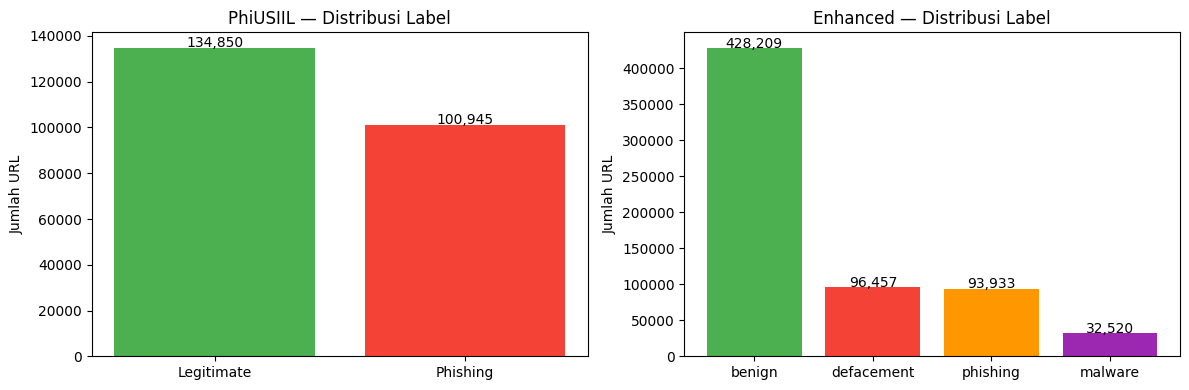

In [ ]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PhiUSIIL
label_map_phi = {1: 'Legitimate', 0: 'Phishing'}
phi_counts = df_phi['label'].map(label_map_phi).value_counts()
axes[0].bar(phi_counts.index, phi_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('PhiUSIIL — Distribusi Label')
axes[0].set_ylabel('Jumlah URL')
for i, v in enumerate(phi_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Enhanced
e26_counts = df_enhanced['type'].value_counts()
axes[1].bar(e26_counts.index, e26_counts.values,
            color=['#4CAF50', '#F44336', '#FF9800', '#9C27B0'])
axes[1].set_title('Enhanced — Distribusi Label')
axes[1].set_ylabel('Jumlah URL')
for i, v in enumerate(e26_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=120, bbox_inches='tight')
plt.show()

### Menghapus data yang duplikat

In [ ]:
# PhiUSIIL
sebelum_phi = len(df_phi)
url_col_phi = 'URL'
df_phi = df_phi.drop_duplicates(subset=[url_col_phi], keep='first')
df_phi = df_phi.reset_index(drop=True)
print(f'PhiUSIIL — Sebelum: {sebelum_phi:,} | Setelah: {len(df_phi):,} | 'f'Duplikat dihapus: {sebelum_phi - len(df_phi):,}')

# Enhanced
sebelum_enhanced = len(df_enhanced)
url_col_enhanced = 'url'
df_enhanced = df_enhanced.drop_duplicates(subset=[url_col_enhanced], keep='first')
df_enhanced = df_enhanced.reset_index(drop=True)
print(f'Enhanced — Sebelum: {sebelum_enhanced:,} | Setelah: {len(df_enhanced):,} | 'f'Duplikat dihapus: {sebelum_enhanced - len(df_enhanced):,}')

PhiUSIIL — Sebelum: 235,795 | Setelah: 235,370 | Duplikat dihapus: 425
Enhanced — Sebelum: 651,191 | Setelah: 640,081 | Duplikat dihapus: 11,110


### Menangani missing values

In [ ]:
def tangani_missing(df, nama, threshold=0.40):
    print(f'\n=== {nama} ===')
    missing_pct = df.isnull().mean()

    # hapus kolom
    kolom_hapus = missing_pct[missing_pct > threshold].index.tolist()
    if kolom_hapus:
        df = df.drop(columns=kolom_hapus)
        print(f'Kolom dihapus (missing >{threshold*100:.0f}%): {kolom_hapus}')
    else:
        print(f'Tidak ada kolom dengan missing >{threshold*100:.0f}%')

    # isi kolom
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f'  [{col}] diisi dengan median: {median_val:.4f}')
            else:
                modus_val = df[col].mode()[0]
                df[col] = df[col].fillna(modus_val)
                print(f'  [{col}] diisi dengan modus: {modus_val}')

    total_missing_sisa = df.isnull().sum().sum()
    print(f'Total missing setelah cleaning: {total_missing_sisa}')
    return df

df_phi   = tangani_missing(df_phi,   'PhiUSIIL')
df_enhanced  = tangani_missing(df_enhanced,  'Enhanced')


=== PhiUSIIL ===
Tidak ada kolom dengan missing >40%
Total missing setelah cleaning: 0

=== Enhanced ===
Tidak ada kolom dengan missing >40%
  [type] diisi dengan modus: benign
  [label] diisi dengan median: 0.0000
  [domain] diisi dengan modus: en.wikipedia.org
Total missing setelah cleaning: 0


### Valiidasi dan normalisasi  format

In [ ]:
def validasi_url(url):
    """Return True jika URL valid, False jika tidak."""
    if not isinstance(url, str):
        return False
    url = url.strip()
    if len(url) < 5 or len(url) > 2000:
        return False
    # minimal domain harus mengandung titik
    if '.' not in url:
        return False
    # cek pattern URL dasar
    pattern = re.compile(
        r'^(https?://)?'
        r'[\w\-]+(\.[\w\-]+)+'
        r'(/[^\s]*)?$',
        re.IGNORECASE
    )
    return bool(pattern.match(url))

def bersihkan_url(df, url_col):
    sebelum = len(df)
    df[url_col] = df[url_col].astype(str).str.strip().str.lower()
    # filter URL
    mask_valid = df[url_col].apply(validasi_url)
    df = df[mask_valid].reset_index(drop=True)
    sesudah = len(df)
    print(f'URL tidak valid : {sebelum - sesudah:,} baris')
    print(f'Sisa data       : {sesudah:,} baris')
    return df

print('=== PhiUSIIL ===')
df_phi = bersihkan_url(df_phi, url_col_phi)
print('\n=== Enhanced ===')
df_enhanced = bersihkan_url(df_enhanced, url_col_enhanced)

=== PhiUSIIL ===
URL tidak valid : 51 baris
Sisa data       : 235,319 baris

=== Enhanced ===
URL tidak valid : 9,558 baris
Sisa data       : 630,523 baris


### Normalisasi label

In [ ]:
# PhiUSIIL
df_phi['label'] = df_phi['label'].map({1: 0, 0: 1})
print('PhiUSIIL — Distribusi label setelah normalisasi: ')
print(df_phi['label'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

# Enhanced
df_enhanced = df_enhanced[df_enhanced['type'].isin(['phishing', 'benign'])].copy()
df_enhanced['label'] = df_enhanced['type'].map({'phishing': 1, 'benign': 0})
df_enhanced = df_enhanced.drop(columns=['type'])
df_enhanced = df_enhanced.reset_index(drop=True)
print('\nEnhanced — Distribusi label setelah normalisasi: ')
print(df_enhanced['label'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

PhiUSIIL — Distribusi label setelah normalisasi: 
label
Legitimate (0)    134850
Phishing (1)      100469
Name: count, dtype: int64

Enhanced — Distribusi label setelah normalisasi: 
label
Legitimate (0)    427386
Phishing (1)       89141
Name: count, dtype: int64


### Mendeteksi dan menangani outlier (PhiUSIIL)

In [ ]:
import numpy as np

print("--- 🔍 DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---")

# 1. Identifikasi Kolom Numerik (Mengecualikan kolom non-fitur/label)
kolom_exclude = ['URL', 'url', 'label', 'type', 'Date_inspection']
fitur_numerik_phi = [c for c in df_phi.select_dtypes(include=[np.number]).columns if c not in kolom_exclude]
fitur_numerik_enh = [c for c in df_enhanced.select_dtypes(include=[np.number]).columns if c not in kolom_exclude]

def cek_dan_hapus_noise(df, nama_df, fitur_numerik):
    ada_error = False

    # a. Mengecek nilai negatif pada fitur yang seharusnya berupa hitungan (panjang, jumlah)
    for col in fitur_numerik:
        # Kata kunci pencarian kolom di PhiUSIIL dan Enhanced
        if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof', 'nb_']):
            jumlah_negatif = (df[col] < 0).sum()
            if jumlah_negatif > 0:
                print(f"[{nama_df}] ⚠️ ERROR: Ditemukan {jumlah_negatif} baris bernilai negatif pada kolom '{col}'!")
                ada_error = True

    # b. Mengecek fitur rasio atau probabilitas (nilainya wajib di antara 0.0 hingga 1.0)
    for col in fitur_numerik:
        if 'ratio' in col.lower() or 'prob' in col.lower():
            jumlah_mustahil = ((df[col] < 0) | (df[col] > 1)).sum()
            if jumlah_mustahil > 0:
                print(f"[{nama_df}] ⚠️ ERROR: Ditemukan {jumlah_mustahil} baris rasio/probabilitas mustahil pada '{col}'!")
                ada_error = True

    # c. Eksekusi Pembersihan
    if ada_error:
        print(f"\n[{nama_df}] ❌ Ditemukan Noise (Data Mustahil). Memulai penghapusan (drop) baris yang error...")
        ukuran_awal = len(df)

        for col in fitur_numerik:
            if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof', 'nb_']):
                df = df[df[col] >= 0]
            if 'ratio' in col.lower() or 'prob' in col.lower():
                df = df[(df[col] >= 0) & (df[col] <= 1)]

        print(f"[{nama_df}] ✅ Pembersihan selesai! {ukuran_awal - len(df)} baris cacat logika dihapus.")
    else:
        print(f"[{nama_df}] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.")

    return df

# Menjalankan fungsi pada kedua dataset
df_phi = cek_dan_hapus_noise(df_phi, "PhiUSIIL", fitur_numerik_phi)
print("-" * 50)
df_enhanced = cek_dan_hapus_noise(df_enhanced, "Enhanced 2026", fitur_numerik_enh)

--- 🔍 DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---
[PhiUSIIL] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.
--------------------------------------------------
[Enhanced 2026] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.


### Feature selection (PhiUSIIL)

In [ ]:
# fitur yang dalam bentuk URL aja
FITUR_URL_ONLY = [
    # struktur URL
    'URLLength',
    'DomainLength',         # panjang domain
    'IsDomainIP',           # apakah domain berupa IP address
    'URLSimilarityIndex',   # skor kemiripan URL dengan domain asli
    'CharContinuationRate', # rasio karakter berulang
    'TLDLegitimateProb',    # probabilitas TLD legitimate
    'URLCharProb',          # probabilitas karakter URL
    'TLDLength',            # panjang TLD
    'NoOfSubDomain',        # jumlah subdomain
    'HasObfuscation',       # ada obfuskasi?
    'NoOfObfuscatedChar',   # jumlah karakter terobfuskasi
    'ObfuscationRatio',     # rasio obfuskasi
    # karakter khusus
    'NoOfLettersInURL',     # jumlah huruf
    'LetterRatioInURL',     # rasio huruf
    'NoOfDegitsInURL',      # jumlah digit
    'DegitRatioInURL',      # rasio digit
    'NoOfEqualsInURL',      # jumlah tanda '='
    'NoOfQMarkInURL',       # jumlah tanda '?'
    'NoOfAmpersandInURL',   # jumlah tanda '&'
    'NoOfOtherSpecialCharsInURL',  # jumlah karakter khusus lain
    'SpacialCharRatioInURL',       # rasio karakter khusus
    # HTTPS dan keamanan
    'IsHTTPS',              # menggunakan HTTPS?
    'HasSocialNet',         # ada nama social network di URL?
    'HasCopyrightInfo',     # ada kata copyright?
    'HasDescription',       # ada deskripsi?
    # label
    'label'
]

# filter agar hanya kolom yang tersedia di dataset
fitur_tersedia = [f for f in FITUR_URL_ONLY if f in df_phi.columns]
fitur_tidak_ada = [f for f in FITUR_URL_ONLY if f not in df_phi.columns]
print(f'Fitur dipilih  : {len(fitur_tersedia)}')
print(f'Fitur tidak ada di dataset: {fitur_tidak_ada}')
df_phi_selected = df_phi[[url_col_phi] + fitur_tersedia].copy()
print(f'\nShape setelah feature selection: {df_phi_selected.shape}')

Fitur dipilih  : 26
Fitur tidak ada di dataset: []

Shape setelah feature selection: (235319, 27)


Kolom dihapus karena korelasi tinggi: ['NoOfLettersInURL']
Shape akhir: (235319, 26)


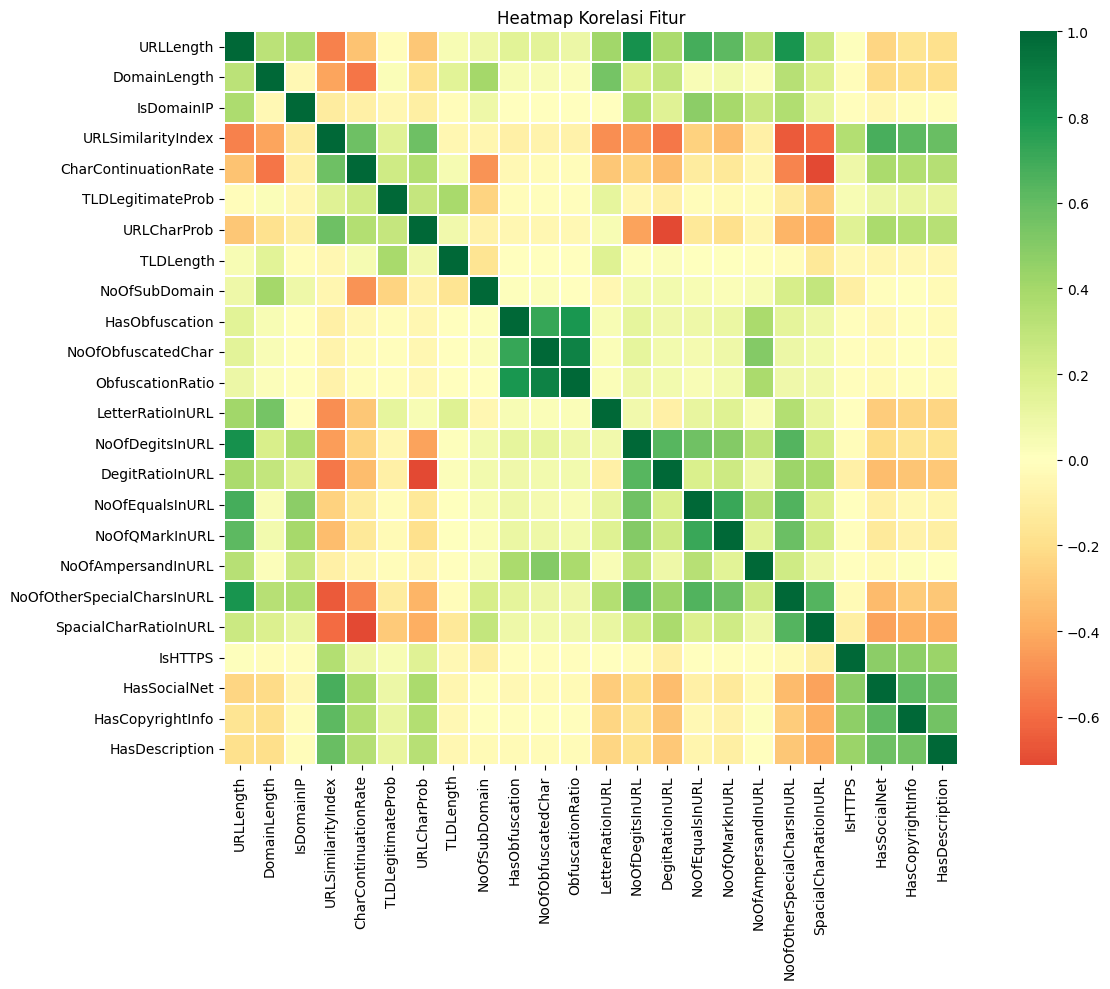

In [ ]:
# cek hubungan antar fitur
X_temp = df_phi_selected.drop(columns=[url_col_phi, 'label'], errors='ignore')
corr_matrix = X_temp.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# menghapus kolom dengan korelasi > 95% dengan kolom lainnya
kolom_drop_korelasi = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
if kolom_drop_korelasi:
    df_phi_selected = df_phi_selected.drop(columns=kolom_drop_korelasi)
    print(f'Kolom dihapus karena korelasi tinggi: {kolom_drop_korelasi}')
else:
    print('Tidak ada kolom dengan korelasi >0.95')
print(f'Shape akhir: {df_phi_selected.shape}')

# heatmap korelasi
plt.figure(figsize=(14, 10))
fitur_plot = [c for c in df_phi_selected.columns if c not in [url_col_phi, 'label']]
sns.heatmap(
    df_phi_selected[fitur_plot].corr(),
    cmap='RdYlGn', center=0, annot=False,
    square=True, linewidths=0.3
)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

### Menanggani class imbalance dengan SMOTE

Distribusi sebelum SMOTE: Counter({np.int64(0): 134850, np.int64(1): 100469})
Distribusi setelah SMOTE : Counter({np.int64(0): 134850, np.int64(1): 134850})
Shape X setelah SMOTE    : (269700, 24)

 === Visualisasi Perbandingan ===


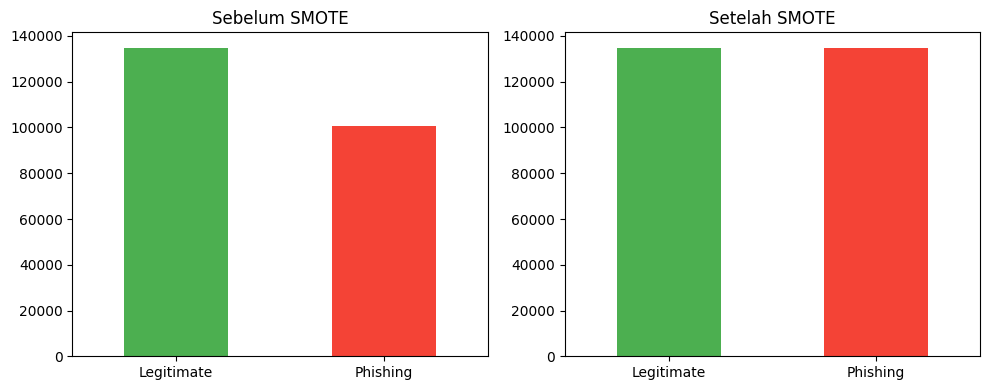

In [ ]:
from imblearn.over_sampling import SMOTE

# memisahkan fitur dan label
fitur_model = [c for c in df_phi_selected.columns
               if c not in [url_col_phi, 'label']]
X = df_phi_selected[fitur_model].values
y = df_phi_selected['label'].values
print(f'Distribusi sebelum SMOTE: {Counter(y)}')

# menerapkan SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f'Distribusi setelah SMOTE : {Counter(y_resampled)}')
print(f'Shape X setelah SMOTE    : {X_resampled.shape}')

# menyimpan kembali nilai baru ke dalam dataframe
df_train_balanced = pd.DataFrame(X_resampled, columns=fitur_model)
df_train_balanced['label'] = y_resampled

# membandingkan sebelum dan sesudah SMOTE dengan visualisasi
print("\n === Visualisasi Perbandingan ===")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y).value_counts().plot(kind='bar', ax=axes[0],
    color=['#4CAF50','#F44336'], title='Sebelum SMOTE')
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1],
    color=['#4CAF50','#F44336'], title='Setelah SMOTE')
axes[0].set_xticklabels(['Legitimate','Phishing'], rotation=0)
axes[1].set_xticklabels(['Legitimate','Phishing'], rotation=0)
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

### Normalisasi fitur menggunakan MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

fitur_scale = [c for c in df_train_balanced.columns if c != 'label']

scaler = MinMaxScaler()
df_train_balanced[fitur_scale] = scaler.fit_transform(
    df_train_balanced[fitur_scale]
)

# menyimpan scaler agar dapat dipakai saat inferensi di API Flask
joblib.dump(scaler, 'scaler_epiccsafe.pkl')
print('Scaler disimpan: scaler_epiccsafe.pkl')
print('PENTING: File scaler ini harus disertakan bersama model ML!')
print(f'\nContoh nilai setelah scaling:')
print(df_train_balanced[fitur_scale[:5]].describe().round(4))

Scaler disimpan: scaler_epiccsafe.pkl
PENTING: File scaler ini harus disertakan bersama model ML!

Contoh nilai setelah scaling:
         URLLength  DomainLength   IsDomainIP  URLSimilarityIndex  \
count  269700.0000   269700.0000  269700.0000         269700.0000   
mean        0.0130        0.1684       0.0032              0.7468   
std         0.0194        0.0908       0.0563              0.2997   
min         0.0000        0.0000       0.0000              0.0000   
25%         0.0063        0.1132       0.0000              0.5121   
50%         0.0085        0.1509       0.0000              1.0000   
75%         0.0125        0.1981       0.0000              1.0000   
max         1.0000        1.0000       1.0000              1.0000   

       CharContinuationRate  
count           269700.0000  
mean                 0.8309  
std                  0.2228  
min                  0.0000  
25%                  0.6562  
50%                  1.0000  
75%                  1.0000  
max      

### Membersihkan dataset enhanced dan ekstraksi fitur URL

In [ ]:
import tldextract

def ekstrak_fitur_url(url):
    """Ekstrak fitur numerik dari raw URL string."""
    try:
        url = str(url).strip()
        extracted = tldextract.extract(url)
        domain = extracted.domain
        tld    = extracted.suffix

        features = {
            'URLLength'            : len(url),
            'DomainLength'         : len(domain),
            'IsDomainIP'           : int(bool(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', domain))),
            'TLDLength'            : len(tld),
            'NoOfSubDomain'        : url.count('.') - 1 if url.count('.') > 0 else 0,
            'HasObfuscation'       : int(any(c in url for c in ['%', '0x', r'\x'])),
            'NoOfObfuscatedChar'   : url.count('%'),
            'LetterRatioInURL'     : sum(c.isalpha() for c in url) / max(len(url), 1),
            'NoOfDegitsInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'DegitRatioInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'NoOfEqualsInURL'      : url.count('='),
            'NoOfQMarkInURL'       : url.count('?'),
            'NoOfAmpersandInURL'   : url.count('&'),
            'NoOfOtherSpecialCharsInURL': sum(not c.isalnum() and c not in ':/.-_?=&%' for c in url),
            'SpacialCharRatioInURL': sum(not c.isalnum() for c in url) / max(len(url), 1),
            'IsHTTPS'              : int(url.startswith('https://')),
            'HasSocialNet'         : int(any(s in url for s in ['facebook','twitter','instagram','telegram','whatsapp'])),
        }
        features['ObfuscationRatio'] = features['NoOfObfuscatedChar'] / max(features['URLLength'], 1)
        features['URLSimilarityIndex'] = 0.0
        features['CharContinuationRate'] = 0.0
        features['TLDLegitimateProb'] = 0.0
        features['URLCharProb'] = 0.0
        features['HasCopyrightInfo'] = 0
        features['HasDescription'] = 0

        return features
    except Exception:
        return None

print('Mengekstrak fitur dari URL Enhanced ... (dalam beberapa menit)')
fitur_list = df_enhanced[url_col_enhanced].apply(ekstrak_fitur_url)

# menghapus baris yang tidak berhasil diekstrak
mask_valid = fitur_list.notna()
df_enhanced_features = pd.DataFrame(fitur_list[mask_valid].tolist())
df_enhanced_features['label'] = df_enhanced.loc[mask_valid, 'label'].values
required_columns = fitur_model

# menambahkan kolom yang hilang ke df_enhanced_features dengan nilai default (misalnya, 0,0)
for col in required_columns:
    if col not in df_enhanced_features.columns:
        df_enhanced_features[col] = 0.0

# menghapus kolom-kolom tambahan yang tidak tercantum dalam required_columns (kecuali ‘label’)
extra_columns = [col for col in df_enhanced_features.columns if col not in required_columns and col != 'label']
if extra_columns:
    df_enhanced_features = df_enhanced_features.drop(columns=extra_columns)

# mengatur ulang urutan kolom agar sesuai dengan urutan di `fitur_model`
df_enhanced_features = df_enhanced_features[required_columns + ['label']]
fitur_scale_enhanced = [c for c in df_enhanced_features.columns if c != 'label']
df_enhanced_features[fitur_scale_enhanced] = scaler.transform(df_enhanced_features[fitur_scale_enhanced])
print(f'Shape Enhanced setelah ekstraksi fitur: {df_enhanced_features.shape}')
print(f'Distribusi label: {dict(df_enhanced_features["label"].value_counts())}')

Mengekstrak fitur dari URL Enhanced ... (dalam beberapa menit)
Shape Enhanced setelah ekstraksi fitur: (516527, 25)
Distribusi label: {0: np.int64(427386), 1: np.int64(89141)}


### Menyimpan dataset yang sudah bersih

In [ ]:
# menyimpan training data
df_train_balanced.to_csv('train_cleaned.csv', index=False)
print(f'Simpan: train_cleaned.csv  — {df_train_balanced.shape}')

# menyimpan test data
df_enhanced_features.to_csv('test_cleaned.csv', index=False)
print(f'Simpan: test_cleaned.csv   — {df_enhanced_features.shape}')

# hasil
print('\n' + '='*55)
print('HASIL DATA CLEANING')
print('='*55)
print(f'Train set  : {len(df_train_balanced):,} baris, {df_train_balanced.shape[1]-1} fitur')
print(f'  - Legitimate : {(df_train_balanced.label==0).sum():,}')
print(f'  - Phishing   : {(df_train_balanced.label==1).sum():,}')
print(f'Test set   : {len(df_enhanced_features):,} baris, {df_enhanced_features.shape[1]-1} fitur')
print(f'  - Legitimate : {(df_enhanced_features.label==0).sum():,}')
print(f'  - Phishing   : {(df_enhanced_features.label==1).sum():,}')
print('='*55)
print('\nFile output:')
print('  train_cleaned.csv       → digunakan untuk training model ML')
print('  test_cleaned.csv        → digunakan untuk validasi akhir model')
print('  scaler_epiccsafe.pkl    → wajib disertakan di Flask API')
print('\nData cleaning selesai  ✅')

Simpan: train_cleaned.csv  — (269700, 25)
Simpan: test_cleaned.csv   — (516527, 25)

HASIL DATA CLEANING
Train set  : 269,700 baris, 24 fitur
  - Legitimate : 134,850
  - Phishing   : 134,850
Test set   : 516,527 baris, 24 fitur
  - Legitimate : 427,386
  - Phishing   : 89,141

File output:
  train_cleaned.csv       → digunakan untuk training model ML
  test_cleaned.csv        → digunakan untuk validasi akhir model
  scaler_epiccsafe.pkl    → wajib disertakan di Flask API

Data cleaning selesai  ✅


## Model Training

### Train test split

In [ ]:
from sklearn.model_selection import train_test_split

# load training data yang sudah bersih
df_train = pd.read_csv('train_cleaned.csv')

# memisahkan fitur dan label
X = df_train.drop(columns=['label'])
y = df_train['label']

print('Shape data sebelum split:')
print(f'  X : {X.shape}')
print(f'  y : {y.shape}')
print(f'  Distribusi label: {dict(y.value_counts())}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('\nHasil Split:')
print(f'  X_train : {X_train.shape}  — {len(X_train):,} baris')
print(f'  X_test  : {X_test.shape}   — {len(X_test):,} baris')
print(f'\nDistribusi label di X_train:')
print(f'  Legitimate (0) : {(y_train==0).sum():,}')
print(f'  Phishing   (1) : {(y_train==1).sum():,}')
print(f'\nDistribusi label di X_test:')
print(f'  Legitimate (0) : {(y_test==0).sum():,}')
print(f'  Phishing   (1) : {(y_test==1).sum():,}')

# load final (Enhanced 2026) — disimpan untuk validasi akhir
df_final_test = pd.read_csv('test_cleaned.csv')
X_final = df_final_test.drop(columns=['label'])
y_final = df_final_test['label']

print('\n' + '='*50)
print('RINGKASAN SPLIT')
print('='*50)
print(f'X_train  : {len(X_train):,} baris  → latih Random Forest')
print(f'X_test   : {len(X_test):,} baris   → validasi awal')
print(f'X_final  : {len(X_final):,} baris → validasi akhir (Enhanced 2026)')
print('='*50)

### Training model

## Risk Scoring

### Evaluasi